# Squeeze Pump Detection — v4b training notebook

Configurable retrain of the v4b model with:
- training / validation date windows
- BTC-feature toggle (29 vs 25 features)
- two data-format options:
    1. **stacked_parquet** — `data/{SYMBOL}_{TAG}.parquet` (legacy notebook style)
    2. **csv_folders** — `data_standard/{SYMBOL}_{TAG}/YYYY-MM-DD.csv` (production format)

Outputs:
- a saved XGBoost model (`MODEL_OUT`)
- validation plots (PR / ROC / score histogram / monthly signal counts)
- a long/short signals CSV over the validation window


In [1]:
# ── Setup ────────────────────────────────────────────────────────────
import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (precision_recall_curve, roc_curve, auc,
                             average_precision_score)

# Make squeeze_pump_v4b/core.py importable.
NB_DIR = Path.cwd()
for cand in [NB_DIR / "squeeze_pump_v4b", NB_DIR.parent / "squeeze_pump_v4b"]:
    if cand.is_dir():
        sys.path.insert(0, str(cand))
        REPO = cand.parent
        break
else:
    raise RuntimeError("squeeze_pump_v4b/ not found relative to notebook")

from core import compute_features, _NON_BTC_FEATURES, _BTC_FEATURES, Config
print("repo =", REPO)


repo = /Users/cfan/Documents/projects/202604_dailyStrategy


## 1. User-editable config

Change paths, dates, BTC toggle, and data format here. Everything below pulls from `cfg`.

In [2]:
# ── Data source ──────────────────────────────────────────────────────
DATA_FORMAT = "csv_folders"          # "stacked_parquet" or "csv_folders"
DATA_DIR    = REPO / "data_standard" # for stacked_parquet, point at data/ or data2/

# ── Feature toggles ──────────────────────────────────────────────────
INCLUDE_BTC_FEATURES = False
BTC_SYMBOL           = "BTCUSDT"
BTC_SOURCE_TAG       = "binance_spot"   # only used when INCLUDE_BTC_FEATURES=True

# ── Universe ─────────────────────────────────────────────────────────
PRIMARY_TAG = "binance_futures"
SPOT_TAGS   = ["binance_spot", "bybit_spot", "okex_spot", "bitget_spot"]
PERP_TAGS   = ["binance_futures", "bybit_perps", "okex_swap"]

# ── Train / validation windows (UTC) ─────────────────────────────────
# These match the dates the original notebook (squeeze_pump_detection_v4b.ipynb)
# split on at its last run — earliest-70 % / latest-30 % of its data span.
# The original had data 2025-07-01 → 2026-04-20; our local data may start
# later (the loader silently picks up whatever is on disk for these windows).
TRAIN_START = "2025-07-01 00:00:00"
TRAIN_END   = "2026-01-22 12:00:00"
VALID_START = "2026-01-22 16:00:00"
VALID_END   = "2026-04-20 20:00:00"

# ── Label definition (notebook v4b best) ─────────────────────────────
LABEL_PUMP_THRESHOLD = 1.5     # peak forward return ≥ 150 %
LABEL_FORWARD_HOURS  = 14*24   # within 14 days
LABEL_MIN_HISTORY_H  = 3*24    # need ≥ 3 days of prior history

# ── Hard pre-filter ──────────────────────────────────────────────────
HF_OI_COIN_3D_MIN = 30
HF_OI_COIN_7D_MIN = 0
HF_TOTAL_CVD_MIN  = 0
HF_RET_3D_MIN     = 0

# ── Entry/exit (used in the validation simulation) ───────────────────
ENTRY_THRESHOLD = 0.90
TRAIL_PCT       = 0.30
STOP_LOSS_PCT   = 0.50
MAX_HOLD_HOURS  = 48

# ── Outputs ──────────────────────────────────────────────────────────
MODEL_OUT   = NB_DIR / "model_v4b_retrained.json"
SIGNALS_OUT = NB_DIR / "validation_signals.csv"

# ── Build the Config object expected by core.compute_features ────────
cfg = Config(
    live_data_path=Path(DATA_DIR), model_path=MODEL_OUT,
    state_path=Path("/tmp/_train_state.json"),
    log_path=Path("/tmp/_train_log.jsonl"),
    primary_tag=PRIMARY_TAG, spot_tags=SPOT_TAGS, perp_tags=PERP_TAGS,
    known_tags=PERP_TAGS + SPOT_TAGS,
    include_btc_features=INCLUDE_BTC_FEATURES,
    btc_symbol=BTC_SYMBOL, btc_source_tag=BTC_SOURCE_TAG,
    entry_threshold=ENTRY_THRESHOLD, trail_pct=TRAIL_PCT,
    stop_loss_pct=STOP_LOSS_PCT, max_hold_hours=MAX_HOLD_HOURS,
    oi_coin_3d_chg_pct_min=HF_OI_COIN_3D_MIN,
    oi_coin_7d_chg_pct_min=HF_OI_COIN_7D_MIN,
    total_cvd_7d_min=HF_TOTAL_CVD_MIN, ret_3d_pct_min=HF_RET_3D_MIN,
    lookback_hours=240, required_history_days=7,
    recheck_interval_sec=5, max_wait_min=10,
    probe_symbols=["BTCUSDT"], probe_tag=PRIMARY_TAG,
)
cfg.features = _NON_BTC_FEATURES + (_BTC_FEATURES if INCLUDE_BTC_FEATURES else [])

print(f"data format : {DATA_FORMAT}")
print(f"data dir    : {DATA_DIR}")
print(f"features    : {len(cfg.features)} ({'with BTC' if INCLUDE_BTC_FEATURES else 'no BTC'})")
print(f"train       : {TRAIN_START}  →  {TRAIN_END}")
print(f"valid       : {VALID_START}  →  {VALID_END}")
print(f"model out   : {MODEL_OUT}")
print(f"signals out : {SIGNALS_OUT}")


data format : csv_folders
data dir    : /Users/cfan/Documents/projects/202604_dailyStrategy/data_standard
features    : 25 (no BTC)
train       : 2025-07-01 00:00:00  →  2026-01-22 12:00:00
valid       : 2026-01-22 16:00:00  →  2026-04-20 20:00:00
model out   : /Users/cfan/Documents/projects/202604_dailyStrategy/notebooks/model_v4b_retrained.json
signals out : /Users/cfan/Documents/projects/202604_dailyStrategy/notebooks/validation_signals.csv


## 2. Load raw data

Two paths supported. Both produce a flat dict
`raw[(NORM_SYMBOL, TAG)] -> DataFrame` of hourly bars. Symbol normalization
matches the notebook (OKEx hyphens are stripped).

In [3]:
def normalize_symbol(raw_sym, tag):
    s = raw_sym.upper()
    if "okex" in tag.lower():
        s = s.replace("-USDT-SWAP", "USDT").replace("-USDT", "USDT")
    return s


def load_stacked_parquet(data_dir: Path, tags):
    out = {}
    for pq in sorted(Path(data_dir).glob("*.parquet")):
        stem = pq.stem
        matched = next((t for t in tags if stem.endswith("_" + t)), None)
        if matched is None:
            continue
        norm = normalize_symbol(stem[: -(len(matched) + 1)], matched)
        df = pd.read_parquet(pq)
        if df.empty or "ts" not in df.columns:
            continue
        df["ts"] = pd.to_datetime(df["ts"], utc=True)
        key = (norm, matched)
        out[key] = pd.concat([out[key], df], ignore_index=True) if key in out else df
    for k in out:
        out[k] = (out[k].dropna(subset=["ts"]).sort_values("ts")
                       .drop_duplicates(subset=["ts"], keep="last")
                       .reset_index(drop=True))
    return out


_DATE_RE = re.compile(r"^(\d{4}-\d{2}-\d{2})\.csv$")


def load_csv_folders(data_dir: Path, tags, start_d, end_d):
    out = {}
    for sub in sorted(Path(data_dir).iterdir()):
        if not sub.is_dir():
            continue
        matched = next((t for t in tags if sub.name.endswith("_" + t)), None)
        if matched is None:
            continue
        norm = sub.name[: -(len(matched) + 1)]
        frames = []
        for f in sub.iterdir():
            m = _DATE_RE.match(f.name)
            if not m:
                continue
            d = pd.Timestamp(m.group(1)).date()
            if start_d <= d <= end_d:
                # round_trip parser is required for bit-exact recovery
                # of float64 values written by codes/convert_data.py.
                df = pd.read_csv(f, float_precision="round_trip")
                if df.empty:
                    continue
                df["ts"] = pd.to_datetime(df["ts"], utc=True)
                frames.append(df)
        if frames:
            out[(norm, matched)] = (pd.concat(frames, ignore_index=True)
                                       .sort_values("ts")
                                       .drop_duplicates(subset=["ts"], keep="last")
                                       .reset_index(drop=True))
    return out


all_tags = list(dict.fromkeys([PRIMARY_TAG] + SPOT_TAGS + PERP_TAGS))
load_start = pd.Timestamp(TRAIN_START) - pd.Timedelta(days=14)  # extra for lookback
load_end   = pd.Timestamp(VALID_END)   + pd.Timedelta(days=20)   # extra for forward labels

print(f"loading {DATA_FORMAT} from {DATA_DIR} ...")
if DATA_FORMAT == "stacked_parquet":
    raw = load_stacked_parquet(DATA_DIR, all_tags)
elif DATA_FORMAT == "csv_folders":
    raw = load_csv_folders(DATA_DIR, all_tags, load_start.date(), load_end.date())
else:
    raise ValueError(f"unknown DATA_FORMAT {DATA_FORMAT}")

symbols = sorted({s for (s, t) in raw if t == PRIMARY_TAG})
print(f"  {len(raw)} (symbol, tag) groups, {len(symbols)} symbols on {PRIMARY_TAG}")


loading csv_folders from /Users/cfan/Documents/projects/202604_dailyStrategy/data_standard ...


  2414 (symbol, tag) groups, 517 symbols on binance_futures


## 3. Compute features (29 or 25 — depending on BTC toggle)

Reuses `core.compute_features` so the training-time math matches the
production code 1:1.

In [4]:
btc_bars = None
if INCLUDE_BTC_FEATURES:
    key = (BTC_SYMBOL, BTC_SOURCE_TAG)
    if key not in raw:
        raise RuntimeError(f"BTC data missing: {key}. "
                           "Either disable BTC features or add the BTC parquet/CSVs.")
    btc_bars = raw[key]

print("computing features ...")
parts = []
for i, sym in enumerate(symbols):
    bundle = {tag: df for (s, tag), df in raw.items() if s == sym}
    if PRIMARY_TAG not in bundle:
        continue
    feats = compute_features(bundle, btc_bars, sym, cfg)
    if not feats.empty:
        parts.append(feats)
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(symbols)}")

features_df = pd.concat(parts, ignore_index=True)
print(f"  {len(features_df):,} rows, {features_df['symbol'].nunique()} symbols")


computing features ...


  200/517


  400/517


  3,272,352 rows, 517 symbols


## 4. Pump labels (peak-forward return ≥ 150 % within 14 days)

Computed on the 1h close series (more precise than the 4h grid) and
joined back to the 4h feature rows.

In [5]:
def _to_naive_ns(series):
    s = pd.to_datetime(series, utc=True)
    return s.dt.tz_convert("UTC").dt.tz_localize(None).to_numpy(dtype="datetime64[ns]")


def label_pumps_for_symbol(primary_df, feat_4h, threshold, fwd_h, min_hist_h):
    primary_df = primary_df.sort_values("ts").reset_index(drop=True)
    closes = primary_df["close"].values
    ts_ns  = _to_naive_ns(primary_df["ts"])
    target = _to_naive_ns(feat_4h["ts"])
    n = len(primary_df)
    out = np.zeros(len(feat_4h), dtype=int)
    for i, t_naive in enumerate(target):
        j = np.searchsorted(ts_ns, t_naive, side="left")
        if j >= n or ts_ns[j] != t_naive:
            continue
        if j < min_hist_h:
            continue
        c0 = closes[j]
        if not np.isfinite(c0) or c0 <= 0:
            continue
        end = min(j + fwd_h + 1, n)
        fwd = closes[j + 1:end]
        if len(fwd) == 0:
            continue
        peak = np.nanmax(fwd)
        if not np.isfinite(peak):
            continue
        if peak / c0 - 1 >= threshold:
            out[i] = 1
    return out


print("labeling ...")
labels_per_sym = []
for sym, g in features_df.groupby("symbol"):
    primary = raw.get((sym, PRIMARY_TAG))
    if primary is None:
        gg = g.copy(); gg["pump_label"] = 0
    else:
        gg = g.copy()
        gg["pump_label"] = label_pumps_for_symbol(
            primary, g, LABEL_PUMP_THRESHOLD, LABEL_FORWARD_HOURS, LABEL_MIN_HISTORY_H
        )
    labels_per_sym.append(gg)

features_df = pd.concat(labels_per_sym, ignore_index=True)
pos_rate_all = features_df["pump_label"].mean()
print(f"  positive rate (all rows): {pos_rate_all:.4f}  ({features_df['pump_label'].sum()} positives)")


labeling ...


  positive rate (all rows): 0.0120  (39301 positives)


## 5. Train / validation split (UNFILTERED — exact match to original v4b)

Match the original notebook's flow precisely:
1. Drop rows with NaN target.
2. Fill NaN/inf features with 0 on the FULL set (so the model sees the
   same imputed values it will see at inference time).
3. Split by ts: `train_df` and `valid_df` are **unfiltered**.
4. Compute the hard-filter masks separately — used only later for
   evaluation views (`train_hf`, `valid_hf`).

In [6]:
def apply_hard_filter(df):
    # 3-day-only filter — matches production core.passes_hard_filter.
    # 7-day checks were dropped because the rotating symbol universe means
    # newly listed hot symbols don't have 7d of history yet.
    return ((df["oi_coin_3d_chg_pct"] > HF_OI_COIN_3D_MIN)
          & (df["ret_3d_pct"]         > HF_RET_3D_MIN))


# 1. Drop rows where the target couldn't be computed (insufficient forward
#    history). Mirrors original cell 11 `model_data = bf.dropna(...)`.
model_data = features_df.dropna(subset=["pump_label"]).copy()
# 2. Fill NaN/inf features with 0 (cross-exchange data may be missing).
model_data[cfg.features] = model_data[cfg.features].fillna(0)
model_data[cfg.features] = model_data[cfg.features].replace([np.inf, -np.inf], 0)

# 3. Date-window split (exact dates inherited from original notebook's
#    70 % timestamp split when it last ran).
train_ts_lo = pd.Timestamp(TRAIN_START, tz="UTC")
train_ts_hi = pd.Timestamp(TRAIN_END,   tz="UTC")
valid_ts_lo = pd.Timestamp(VALID_START, tz="UTC")
valid_ts_hi = pd.Timestamp(VALID_END,   tz="UTC")

train_df = model_data[(model_data["ts"] >= train_ts_lo)
                      & (model_data["ts"] <= train_ts_hi)].copy().reset_index(drop=True)
valid_df = model_data[(model_data["ts"] >= valid_ts_lo)
                      & (model_data["ts"] <= valid_ts_hi)].copy().reset_index(drop=True)

# 4. Hard-filter masks — applied AFTER training, only for evaluation.
hard_mask_train = apply_hard_filter(train_df)
hard_mask_valid = apply_hard_filter(valid_df)

print(f"train (unfiltered): {len(train_df):,} rows, "
      f"{int(train_df['pump_label'].sum())} positives "
      f"({train_df['pump_label'].mean()*100:.4f}%)")
print(f"valid (unfiltered): {len(valid_df):,} rows, "
      f"{int(valid_df['pump_label'].sum())} positives "
      f"({valid_df['pump_label'].mean()*100:.4f}%)")
print(f"\n=== Hard filter stats (3-day only — matches production) ===")
print(f"train pass: {hard_mask_train.sum():,}/{len(train_df):,} "
      f"({hard_mask_train.mean()*100:.2f}%)  "
      f"pump rate {train_df.loc[hard_mask_train,'pump_label'].mean()*100:.2f}% "
      f"(baseline {train_df['pump_label'].mean()*100:.4f}%)")
print(f"valid pass: {hard_mask_valid.sum():,}/{len(valid_df):,} "
      f"({hard_mask_valid.mean()*100:.2f}%)  "
      f"pump rate {valid_df.loc[hard_mask_valid,'pump_label'].mean()*100:.2f}% "
      f"(baseline {valid_df['pump_label'].mean()*100:.4f}%)")


train (unfiltered): 2,274,025 rows, 30012 positives (1.3198%)
valid (unfiltered): 996,776 rows, 9277 positives (0.9307%)

=== Hard filter stats (3-day only — matches production) ===
train pass: 56,238/2,274,025 (2.47%)  pump rate 3.60% (baseline 1.3198%)
valid pass: 25,584/996,776 (2.57%)  pump rate 3.63% (baseline 0.9307%)


## 6. Train XGBoost on the FULL unfiltered training set

Hyperparameters identical to the original notebook (cell 15).

In [7]:
X_train = train_df[cfg.features].values
y_train = train_df["pump_label"].values.astype(int)
X_valid = valid_df[cfg.features].values
y_valid = valid_df["pump_label"].values.astype(int)

n_pos = max(1, int(y_train.sum()))
n_neg = int((y_train == 0).sum())
spw = n_neg / n_pos
print(f"scale_pos_weight = {n_neg} / {n_pos} = {spw:.2f}")

clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7,
    scale_pos_weight=spw,
    eval_metric="aucpr",
    n_jobs=-1, random_state=42, verbosity=0,
)
print("Fitting XGBoost on unfiltered training set ...")
clf.fit(X_train, y_train)

# Score every row in train and valid (no filter at scoring time either —
# we will subset to filter-passing rows AFTER).
train_df["pred_xgb"] = clf.predict_proba(X_train)[:, 1]
valid_df["pred_xgb"] = clf.predict_proba(X_valid)[:, 1]

# Filtered evaluation views — analogous to original `train_hf` / `test_hf`.
train_hf = train_df[hard_mask_train].copy()
valid_hf = valid_df[hard_mask_valid].copy()
print(f"train_hf: {len(train_hf):,}   valid_hf: {len(valid_hf):,}")

clf.save_model(str(MODEL_OUT))
print(f"saved → {MODEL_OUT}")


scale_pos_weight = 2244013 / 30012 = 74.77
Fitting XGBoost on unfiltered training set ...


train_hf: 56,238   valid_hf: 25,584
saved → /Users/cfan/Documents/projects/202604_dailyStrategy/notebooks/model_v4b_retrained.json


## 7. Validation evaluation — plots on the FILTERED view

Filter is the eval-time pre-screen (matches the original). Plots and
metrics use `valid_hf` only — i.e. only rows that pass the hard filter
are eligible to become signals.

valid_hf pred  mean: 0.4966  max: 0.9701  ≥0.9: 980


/var/folders/rt/bqj5shyj7nvc3xf0c2mwx24m0000gn/T/ipykernel_35434/178800479.py:41: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sigs["month"] = sigs["ts"].dt.to_period("M").astype(str)


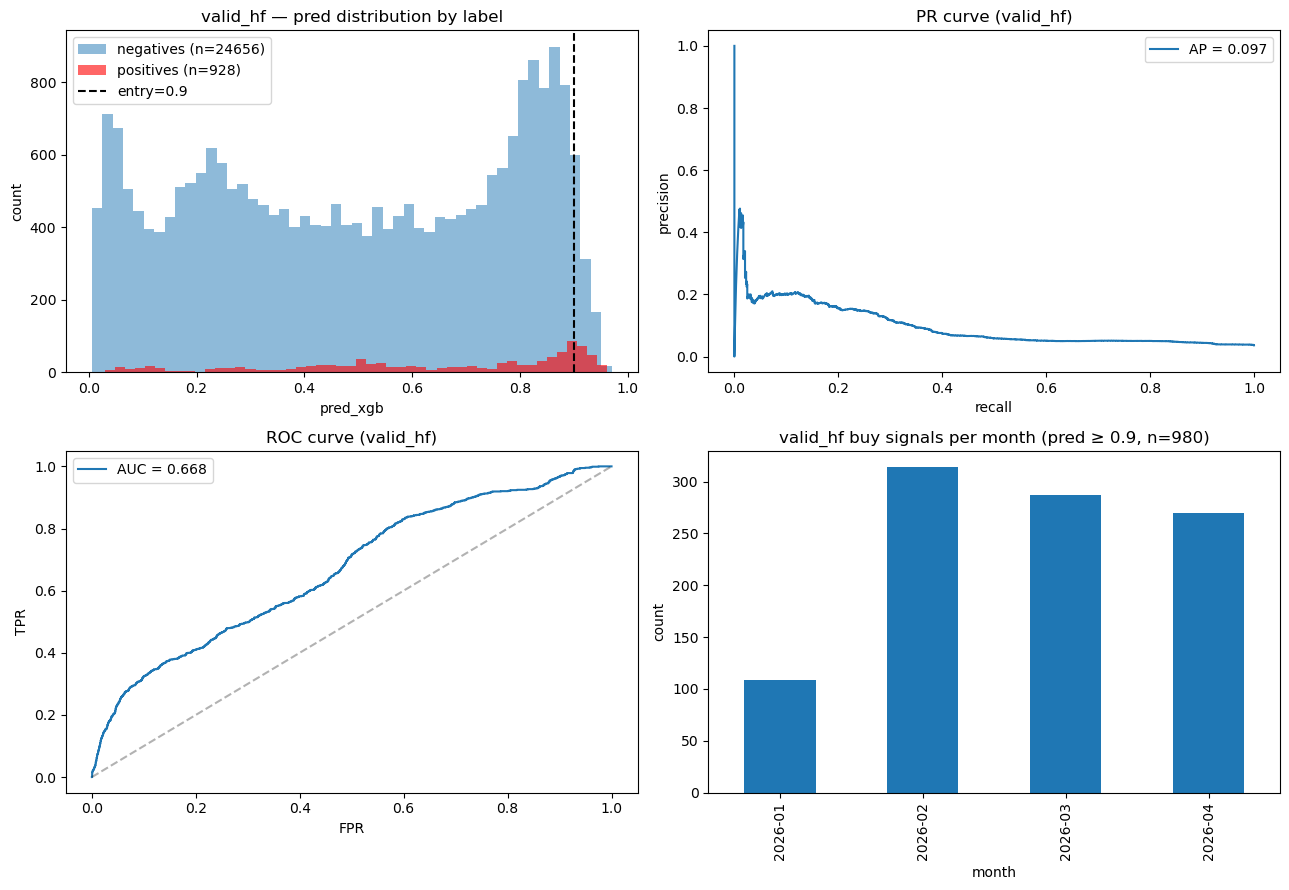

In [8]:
y_valid_hf  = valid_hf["pump_label"].values.astype(int)
pred_valid_hf = valid_hf["pred_xgb"].values

print(f"valid_hf pred  mean: {pred_valid_hf.mean():.4f}  "
      f"max: {pred_valid_hf.max():.4f}  "
      f"≥{ENTRY_THRESHOLD}: {(pred_valid_hf >= ENTRY_THRESHOLD).sum()}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Prediction distribution on filtered validation
ax = axes[0, 0]
neg = valid_hf[valid_hf.pump_label == 0]["pred_xgb"]
pos = valid_hf[valid_hf.pump_label == 1]["pred_xgb"]
ax.hist(neg, bins=50, alpha=0.5, label=f"negatives (n={len(neg)})")
ax.hist(pos, bins=50, alpha=0.6, label=f"positives (n={len(pos)})", color="red")
ax.axvline(ENTRY_THRESHOLD, color="black", ls="--", label=f"entry={ENTRY_THRESHOLD}")
ax.set_xlabel("pred_xgb"); ax.set_ylabel("count"); ax.legend()
ax.set_title("valid_hf — pred distribution by label")

# (b) Precision-recall on filtered validation
ax = axes[0, 1]
prec, rec, _ = precision_recall_curve(y_valid_hf, pred_valid_hf)
ap = average_precision_score(y_valid_hf, pred_valid_hf)
ax.plot(rec, prec, label=f"AP = {ap:.3f}")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.legend()
ax.set_title("PR curve (valid_hf)")

# (c) ROC on filtered validation
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_valid_hf, pred_valid_hf)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend()
ax.set_title("ROC curve (valid_hf)")

# (d) Buy signals per month
ax = axes[1, 1]
sigs = valid_hf[valid_hf["pred_xgb"] >= ENTRY_THRESHOLD].copy()
if len(sigs):
    sigs["month"] = sigs["ts"].dt.to_period("M").astype(str)
    counts = sigs["month"].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax)
    ax.set_title(f"valid_hf buy signals per month (pred ≥ {ENTRY_THRESHOLD}, n={len(sigs)})")
else:
    ax.text(0.5, 0.5, "no signals at this threshold",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("valid_hf buy signals per month")
ax.set_ylabel("count")

plt.tight_layout()
plt.show()


## 8. Long/short signal CSV — backtest-style simulation on validation

Walks the validation period, opens a long when `pred ≥ ENTRY_THRESHOLD`
and the row passes the hard filter, closes on stop_loss / trail_stop /
time_exit (using the production exit rules). Output CSV columns:

| ticker | datetime | long | short | model_pred | side | exit_reason | entry_close | exit_close | ret |
|---|---|---|---|---|---|---|---|---|---|

`long=1` rows mark entries; `short=-1` rows mark exits.

In [9]:
# Per-symbol hourly close lookup for exit walking.
primary_close = {}
for (sym, tag), df in raw.items():
    if tag != PRIMARY_TAG:
        continue
    primary_close[sym] = (df.sort_values("ts")
                            .drop_duplicates(subset=["ts"], keep="last")
                            .set_index("ts")["close"])

records = []
positions = {}                 # sym -> {entry_ts, entry_close, peak, entry_pred}

# Entry candidates only come from valid_hf (filter-passing rows).
# Exits are evaluated on every 4h bar over the validation window so trail/
# stop/time triggers fire at the right moment regardless of filter status.
four_h_ts = sorted(set(valid_df["ts"].tolist()))
buys_by_ts = {ts: g for ts, g in valid_hf.groupby("ts")}

for ts in four_h_ts:
    # ── exit pass (walk hourly closes from each open entry up to ts) ──
    for sym in list(positions):
        pos = positions[sym]
        closes = primary_close.get(sym)
        if closes is None:
            continue
        entry_ts    = pos["entry_ts"]
        time_limit  = entry_ts + pd.Timedelta(hours=MAX_HOLD_HOURS)
        window_end  = min(ts, time_limit)
        try:
            window = closes.loc[entry_ts + pd.Timedelta(hours=1):window_end]
        except KeyError:
            continue
        peak       = pos["peak"]
        stop_price = pos["entry_close"] * (1 - STOP_LOSS_PCT)
        triggered  = None
        for sub_ts, p in window.items():
            if not np.isfinite(p):
                continue
            peak = max(peak, p)
            if p <= stop_price:
                triggered = ("stop_loss",  sub_ts, p); break
            if p <= peak * (1 - TRAIL_PCT):
                triggered = ("trail_stop", sub_ts, p); break
            if sub_ts >= time_limit:
                triggered = ("time_exit",  sub_ts, p); break
        if triggered:
            reason, exit_ts, exit_close = triggered
            records.append({
                "ticker": sym, "datetime": exit_ts.isoformat(),
                "long": 0, "short": -1, "model_pred": pos["entry_pred"],
                "side": "SELL", "exit_reason": reason,
                "entry_close": pos["entry_close"], "exit_close": float(exit_close),
                "ret": float(exit_close) / pos["entry_close"] - 1.0,
            })
            del positions[sym]
        else:
            pos["peak"] = peak

    # ── entry pass at ts (filter-passing rows only) ───────────────────
    candidates = buys_by_ts.get(ts)
    if candidates is None:
        continue
    for _, r in candidates.iterrows():
        sym = r["symbol"]
        if sym in positions:
            continue
        if r["pred_xgb"] < ENTRY_THRESHOLD:
            continue
        positions[sym] = {
            "entry_ts": ts, "entry_close": float(r["close"]),
            "peak": float(r["close"]), "entry_pred": float(r["pred_xgb"]),
        }
        records.append({
            "ticker": sym, "datetime": ts.isoformat(),
            "long": 1, "short": 0, "model_pred": float(r["pred_xgb"]),
            "side": "BUY", "exit_reason": "",
            "entry_close": float(r["close"]), "exit_close": np.nan, "ret": np.nan,
        })

sig_df = pd.DataFrame(records, columns=[
    "ticker", "datetime", "long", "short", "model_pred",
    "side", "exit_reason", "entry_close", "exit_close", "ret",
])
sig_df.to_csv(SIGNALS_OUT, index=False)
print(f"signals written → {SIGNALS_OUT} ({len(sig_df)} rows)")

# Summary stats.
n_buys  = (sig_df["side"] == "BUY").sum()
n_sells = (sig_df["side"] == "SELL").sum()
print(f"  buys: {n_buys}, sells: {n_sells}, still-open: {n_buys - n_sells}")
if n_sells:
    sells = sig_df[sig_df["side"] == "SELL"]
    print(f"  win rate: {(sells['ret'] > 0).mean():.3f}")
    print(f"  mean ret: {sells['ret'].mean():.4f}, median: {sells['ret'].median():.4f}")
    print("  by exit_reason:")
    print(sells.groupby("exit_reason")["ret"].agg(["count", "mean", "median"]))
sig_df.head(20)


signals written → /Users/cfan/Documents/projects/202604_dailyStrategy/notebooks/validation_signals.csv (233 rows)
  buys: 118, sells: 115, still-open: 3
  win rate: 0.322
  mean ret: -0.0730, median: -0.1003
  by exit_reason:
             count      mean    median
exit_reason                           
stop_loss        1 -0.547528 -0.547528
time_exit       71 -0.027758 -0.030193
trail_stop      43 -0.136591 -0.144413


,ticker,datetime,long,short,model_pred,side,exit_reason,entry_close,exit_close,ret
0,NAORISUSDT,2026-01-22T16:00:00+00:00,1,0,0.925784,BUY,,0.032870,NaN,NaN
1,HANAUSDT,2026-01-22T19:00:00+00:00,1,0,0.915508,BUY,,0.024370,NaN,NaN
2,AIAUSDT,2026-01-23T06:00:00+00:00,1,0,0.921757,BUY,,0.247520,NaN,NaN
3,NAORISUSDT,2026-01-24T16:00:00+00:00,0,-1,0.925784,SELL,time_exit,0.032870,0.025360,-0.228476
4,HANAUSDT,2026-01-24T19:00:00+00:00,0,-1,0.915508,SELL,time_exit,0.024370,0.024340,-0.001231
5,AIAUSDT,2026-01-25T06:00:00+00:00,0,-1,0.921757,SELL,time_exit,0.247520,0.213960,-0.135585
6,BTRUSDT,2026-01-26T08:00:00+00:00,1,0,0.900428,BUY,,0.108640,NaN,NaN
7,BOBUSDT,2026-01-26T11:00:00+00:00,1,0,0.902254,BUY,,0.011573,NaN,NaN
8,BTRUSDT,2026-01-27T04:00:00+00:00,0,-1,0.900428,SELL,trail_stop,0.108640,0.081170,-0.252853
9,BTRUSDT,2026-01-27T05:00:00+00:00,1,0,0.904967,BUY,,0.121170,NaN,NaN


## 9. Inspect the signals CSV

In [10]:
print("first 20 signal rows:")
sig_df.head(20)


first 20 signal rows:


,ticker,datetime,long,short,model_pred,side,exit_reason,entry_close,exit_close,ret
0,NAORISUSDT,2026-01-22T16:00:00+00:00,1,0,0.925784,BUY,,0.032870,NaN,NaN
1,HANAUSDT,2026-01-22T19:00:00+00:00,1,0,0.915508,BUY,,0.024370,NaN,NaN
2,AIAUSDT,2026-01-23T06:00:00+00:00,1,0,0.921757,BUY,,0.247520,NaN,NaN
3,NAORISUSDT,2026-01-24T16:00:00+00:00,0,-1,0.925784,SELL,time_exit,0.032870,0.025360,-0.228476
4,HANAUSDT,2026-01-24T19:00:00+00:00,0,-1,0.915508,SELL,time_exit,0.024370,0.024340,-0.001231
5,AIAUSDT,2026-01-25T06:00:00+00:00,0,-1,0.921757,SELL,time_exit,0.247520,0.213960,-0.135585
6,BTRUSDT,2026-01-26T08:00:00+00:00,1,0,0.900428,BUY,,0.108640,NaN,NaN
7,BOBUSDT,2026-01-26T11:00:00+00:00,1,0,0.902254,BUY,,0.011573,NaN,NaN
8,BTRUSDT,2026-01-27T04:00:00+00:00,0,-1,0.900428,SELL,trail_stop,0.108640,0.081170,-0.252853
9,BTRUSDT,2026-01-27T05:00:00+00:00,1,0,0.904967,BUY,,0.121170,NaN,NaN
